<img src='images/header.png'>

# Personal Gym Recommmendation System

** The "Personal Gym Recommendation" project aims to build a system that helps gym-goers get a recommendation system that takes into account the specific fitness preferences for beginners **

The dataset contains the following variables:

* **'1. Sex':** : Indicates the gender of the individual (Male/Female).
* **'2. Age':** Age of the individual in years.
* **'3. Height':** Height of the individual in meters.
* **'4. Weight':** Weight of the individual in kilograms.
* **'5. Hypertension':** Indicates whether the individual has hypertension (Yes/No).
* **'6. Diabetes':** Indicates whether the individual has diabetes (Yes/No).
* **'7. BMI':** Body Mass Index of the individual, calculated as weight in kilograms divided by the square of height in meters.
* **'8. Level':** : Categorizes the individual's weight status based on BMI (e.g., Underweight, Normal, Overweight, Obese).
* **'9. Lower Limmit':** (possibly meant to be "Lower Limit"): Lower limit of the standard weight range for the individual, based on height.
* **'10. Upper Limmit':** (possibly meant to be "Upper Limit"): Upper limit of the standard weight range for the individual, based on height.
* **'11. Standard Weight':** A range indicating the healthy or standard weight range for the individual, given in kilograms.
* **'12. Fat Percentage':** The percentage of the individual's weight that is fat.
* **'13. Fitness Goal':** The individual's fitness goal (e.g., Weight Gain, Weight Loss).
* **'14. Fitness Type:':** : Type of fitness the program is targeting (e.g., Muscular Fitness, Cardiovascular Fitness).
* **'15. Exercises':** Recommended exercises for the individual to meet their fitness goal.
* **'16. Equipment Required':** HThe equipment needed to perform the recommended exercises.
* **'17. Diet':** Recommended diet or foods for the individual to follow, aimed at supporting their fitness goal.
* **'18. Conclusion Recommendation':** A general conclusion or recommendation given to the individual based on their profile and fitness goals.

------------------------------

## Import Necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.multioutput import MultiOutputClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis,QuadraticDiscriminantAnalysis
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, accuracy_score
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,  classification_report, ConfusionMatrixDisplay
from imblearn.combine import SMOTEENN

----------------------------

## Reading Data Set

In [3]:
df = pd.read_excel('dataset/gym recommendation.xlsx')
df.head()

,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Lower Limmit,Upper Limmit,Standard Weight,Fat Percentage,Fitness Goal,Fitness Type,Exercises,Equipment Required,Diet,Conclusion Recommendation
0,Male,18,1.68,47.5,No,No,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,Male,18,1.68,47.5,Yes,No,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...
2,Male,18,1.68,47.5,No,Yes,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Dumbbells, barbells and Blood glucose monitor","Vegetables: (Garlic, Roma Tomatoes, Capers and...",Follow a regular exercise schedule. Adhere to ...
3,Male,18,1.68,47.5,Yes,Yes,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, yoga, deadlifts, bench presses, and ov...","Light athletic shoes, resistance bands, light ...","Vegetables: (Garlic, Roma Tomatoes, Capers, Gr...",Follow a regular exercise schedule. Adhere to ...
4,Male,18,1.68,47.5,No,No,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, Lettuce); ...",Follow a regular exercise schedule. Adhere to ...


----------------------

### Dimensions of dataset

In [4]:
df.shape

(14589, 18)

-----------------------

### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14589 entries, 0 to 14588
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sex                        14589 non-null  object 
 1   Age                        14589 non-null  int64  
 2   Height                     14589 non-null  float64
 3   Weight                     14589 non-null  float64
 4   Hypertension               14589 non-null  object 
 5   Diabetes                   14589 non-null  object 
 6   BMI                        14589 non-null  float64
 7   Level                      14589 non-null  object 
 8   Lower Limmit               14589 non-null  float64
 9   Upper Limmit               14589 non-null  float64
 10  Standard Weight            14589 non-null  object 
 11  Fat Percentage             14589 non-null  float64
 12  Fitness Goal               14589 non-null  object 
 13  Fitness Type               14589 non-null  obj

-------------------

### Data Statistics

In [6]:
df.describe()

,Age,Height,Weight,BMI,Lower Limmit,Upper Limmit,Fat Percentage
count,14589.000000,14589.000000,14589.000000,14589.000000,14589.000000,14589.00000,14589.000000
mean,39.554870,1.699851,70.505991,24.417569,53.633586,72.18826,26.059389
std,13.192655,0.098129,20.030635,6.765144,6.184980,8.32388,9.933972
min,18.000000,1.300000,32.000000,9.520000,31.270000,42.08000,0.740000
25%,28.000000,1.640000,55.000000,18.940000,49.760000,66.97000,18.910000
50%,39.000000,1.680000,70.000000,25.250000,52.210000,70.28000,25.670000
75%,51.000000,1.770000,86.000000,29.320000,57.960000,78.01000,32.440000
max,63.000000,2.030000,130.000000,70.000000,76.240000,102.61000,74.470000


----------------------------

### Data Columns

In [7]:
df.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Hypertension', 'Diabetes', 'BMI',
       'Level', 'Lower Limmit', 'Upper Limmit', 'Standard Weight',
       'Fat Percentage', 'Fitness Goal', 'Fitness Type', 'Exercises',
       'Equipment Required', 'Diet', 'Conclusion Recommendation'],
      dtype='object')

--------------------------

## Data Clearning

### Checking Missinge Values

In [8]:
# Check how many missing values in the dataset
print("The total missing values in this dataset:- " , len(df[df.isnull().any(axis=1)]))

The total missing values in this dataset:-  0


-------------------

#### Handle if Exists by droping

In [9]:
# Handling Missing Values if exist by using dropna  method to drop permanentally
df.dropna(inplace=True)

---------------------------------

### Checing Duplicate Values

In [10]:
print("Number Of Duplicate Values: ",df.duplicated().sum())

Number Of Duplicate Values:  2437


-------------------------------------

### Checking Average of duplicate values

In [11]:
print("Average Of Duplicate Values: ",round(df.duplicated().sum() / df.shape[0] * 100,2),"%")

Average Of Duplicate Values:  16.7 %


----------------

#### handline duplicate values of droping & Overwrite the original dataset

In [12]:
df_unique = df.drop_duplicates()
# Overwrite the original dataframe with the unique one
df = df_unique

--------------------

## Checking outliers

In [13]:
# Define a function to detect outliers based on the IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]

# Columns to check for outliers
columns_to_check = ['Age', 'Height', 'Weight', 'BMI', 'Lower Limmit', 'Upper Limmit', 'Fat Percentage']

# Calculate the number of outliers in each column
outliers_count = {column: detect_outliers_iqr(df, column) for column in columns_to_check}
outliers_count


{'Age': 0,
 'Height': 69,
 'Weight': 0,
 'BMI': 107,
 'Lower Limmit': 39,
 'Upper Limmit': 39,
 'Fat Percentage': 37}

----------------------

## Drop All Outliers from dataset

In [16]:
# Define a function to remove outliers based on the IQR method for a given column
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply the outlier removal for each column individually
df = df.copy()
for column in columns_to_check:
    df = remove_outliers_iqr(df, column)

# Check the new shape of the dataset to see how many records remain
df.shape

(11936, 18)

-----------------------

### Data Statistics After Clearing Data

In [17]:
df.describe()

,Age,Height,Weight,BMI,Lower Limmit,Upper Limmit,Fat Percentage
count,11936.000000,11936.00000,11936.000000,11936.000000,11936.000000,11936.000000,11936.000000
mean,39.372989,1.70165,69.791949,24.079377,53.738145,72.328794,26.057224
std,13.388718,0.09568,19.614286,6.364667,6.071906,8.171633,9.718803
min,18.000000,1.48000,32.000000,9.520000,40.520000,54.540000,0.740000
25%,28.000000,1.64000,54.000000,18.620000,49.760000,66.970000,19.070000
50%,38.000000,1.68000,69.000000,25.075000,52.210000,70.280000,25.825000
75%,51.000000,1.77000,85.000000,28.800000,57.960000,78.010000,32.670000
max,63.000000,1.94000,125.000000,43.820000,69.630000,93.710000,52.890000


-------------------------------------------------------

## Data Visualizations...

### 1. Visualizing for numerical distributions by using Histogram with Matplotlib

=================================================================================

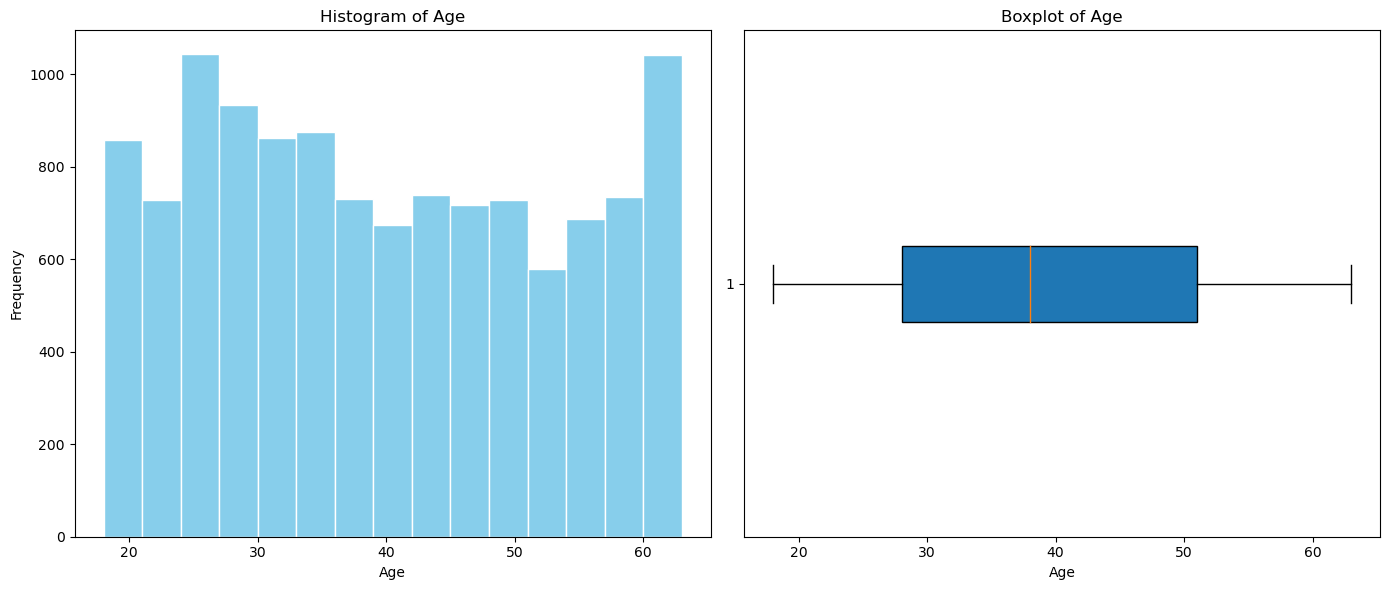

In [18]:
# Plotting histogram and boxplot for 'Age' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=15, color='skyblue', edgecolor='white')
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Age'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Age')
plt.xlabel('Age')

plt.tight_layout()
plt.savefig('visualizations/age.png')
plt.show()

### Age Distribution Analysis
The image consists of two charts: a histogram and a boxplot, both representing the age distribution of a dataset

- **Histogram**: 
  - Ages are spread fairly evenly.
  - Higher frequency around ages 30 and 60.
- **Boxplot**: 
  - Median age around 40.
  - Age range: 20 to 60.
- **Summary**: 
  - Ages are distributed relatively evenly across the dataset.
  - No significant outliers.

------------------------

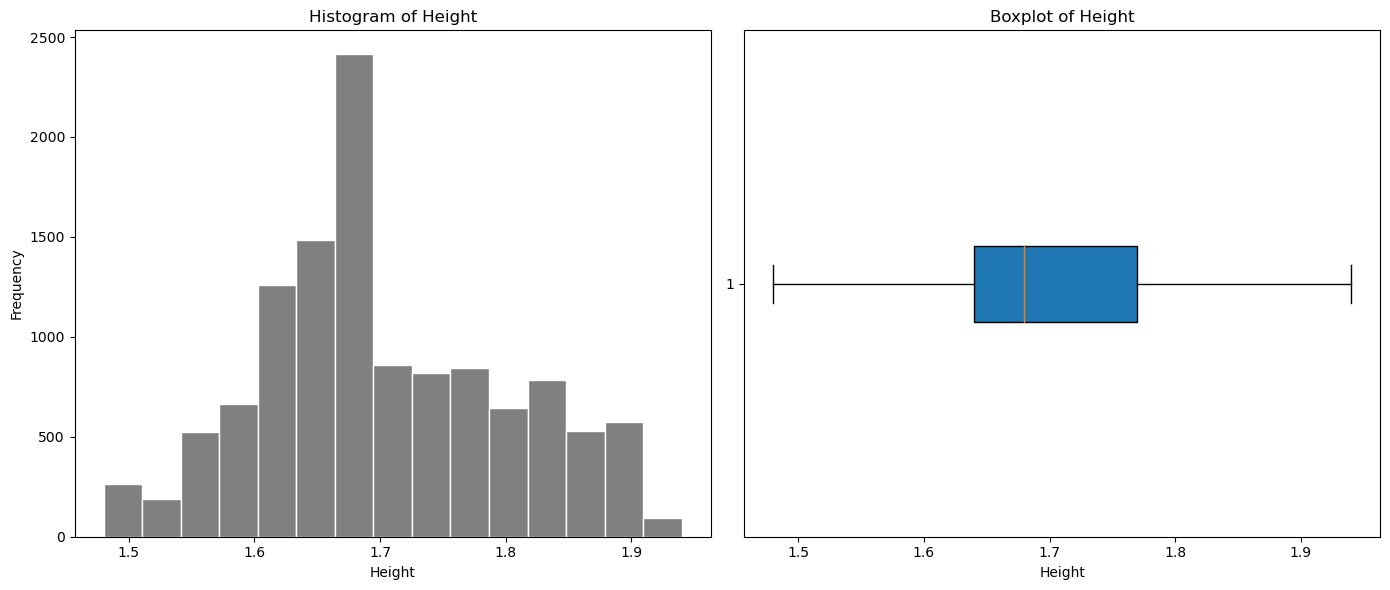

In [19]:
# Plotting histogram and boxplot for 'Height' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Height'], bins=15, color='gray', edgecolor='white')
plt.title('Histogram of Height')
plt.xlabel('Height')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Height'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Height')
plt.xlabel('Height')

plt.tight_layout()
plt.savefig('visualizations/height.png')
plt.show()

### Height Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the height distribution of a dataset.

- **Histogram**: 
  - Most common height range: around 1.7 meters.
  - Less frequent heights: below 1.6 meters and above 1.9 meters.
- **Boxplot**: 
  - Median height around 1.7 meters.
  - Height range: 1.5 to 1.9 meters.
- **Summary**: 
  - Heights are most commonly around 1.7 meters.
  - No significant outliers.


--------------------------

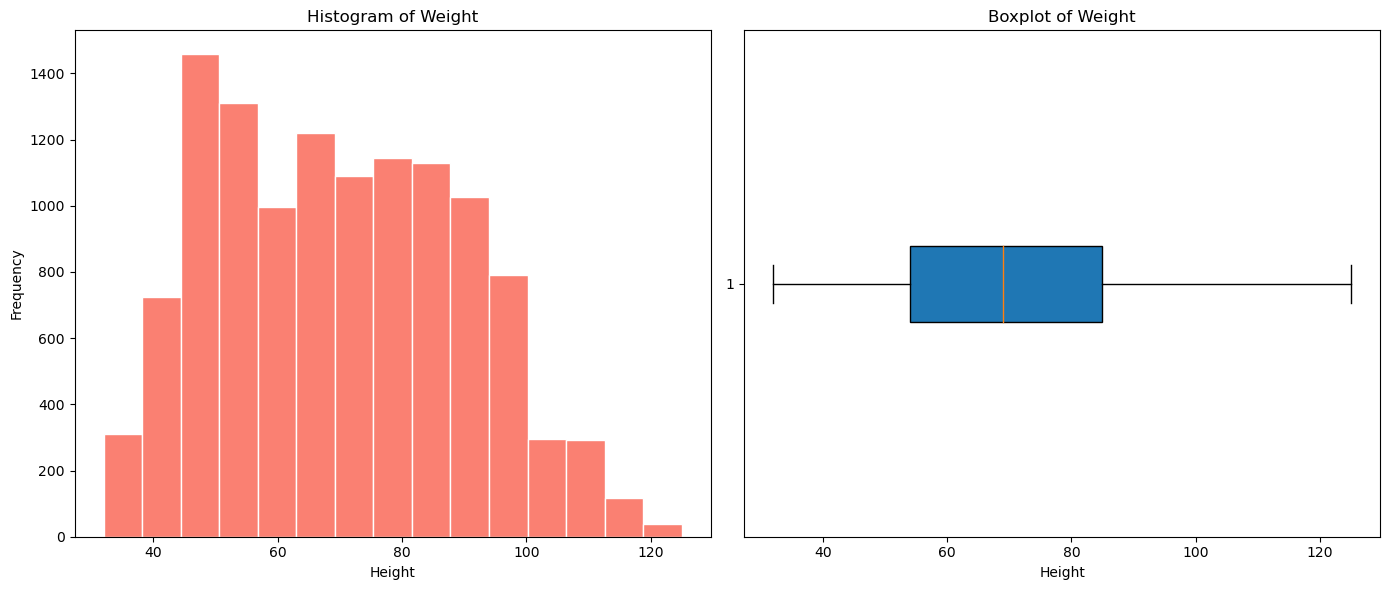

In [20]:
# Plotting histogram and boxplot for 'Weight' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Weight'], bins=15, color='salmon', edgecolor='white')
plt.title('Histogram of Weight')
plt.xlabel('Height')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Weight'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Weight')
plt.xlabel('Height')

plt.tight_layout()
plt.savefig('visualizations/weight.png')
plt.show()

### Weight Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the weight distribution of a dataset.

- **Histogram**: 
  - Most common weight range: 50-60 kg.
  - Less frequent weights: below 40 kg and above 100 kg.
- **Boxplot**: 
  - Median weight around 70 kg.
  - Weight range: 30 to 120 kg.
- **Summary**: 
  - Weights are most commonly around 50-60 kg.
  - No significant outliers.


--------------------------------

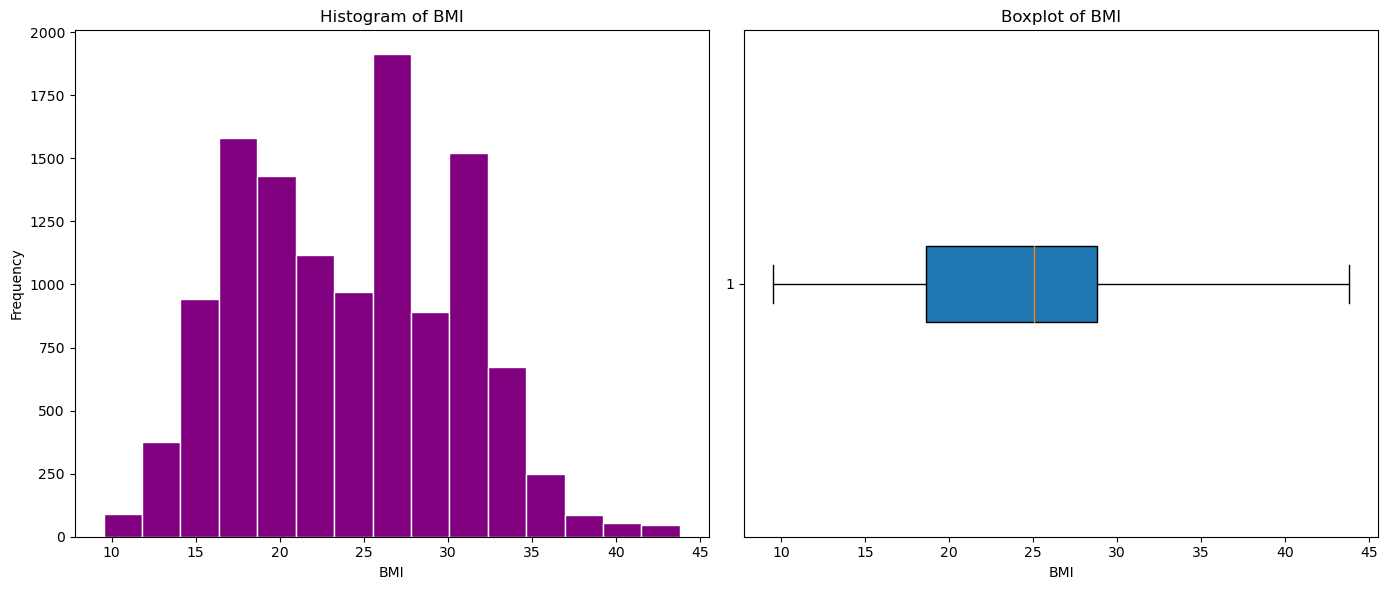

In [21]:
# Plotting histogram and boxplot for 'BMI' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['BMI'], bins=15, color='purple', edgecolor='white')
plt.title('Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['BMI'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of BMI')
plt.xlabel('BMI')

plt.tight_layout()
plt.savefig('visualizations/bmi.png')
plt.show()

### BMI Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the BMI (Body Mass Index) distribution of a dataset.

- **Histogram**: 
  - Most common BMI range: around 25.
  - Less frequent BMI values: below 15 and above 35.
  
- **Boxplot**: 
  - Median BMI around 25.
  - BMI range: 10 to 45.
  
- **Summary**: 
  - BMI values are most commonly around 25.
  - No significant outliers.

-------------------------

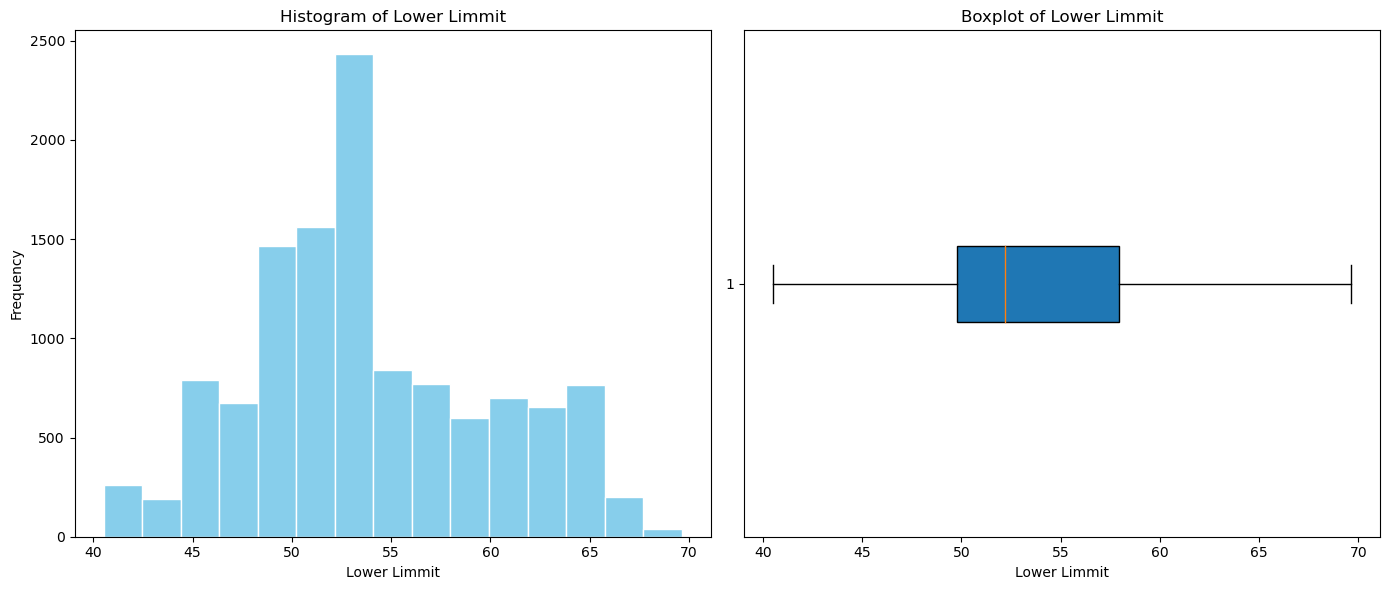

In [22]:
# Plotting histogram and boxplot for 'Lower Limmit' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Lower Limmit'], bins=15, color='skyblue', edgecolor='white')
plt.title('Histogram of Lower Limmit')
plt.xlabel('Lower Limmit')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Lower Limmit'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Lower Limmit')
plt.xlabel('Lower Limmit')

plt.tight_layout()
plt.savefig('visualizations/lower.png')
plt.show()

### Lower Limit Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the lower limit distribution of a dataset.

- **Histogram**: 
  - Most common lower limit range: around 55.
  - Less frequent lower limit values: below 45 and above 65.
- **Boxplot**: 
  - Median lower limit around 55.
  - Lower limit range: 40 to 70.
- **Summary**: 
  - Lower limit values are most commonly around 55.
  - No significant outliers.


--------------------------------------

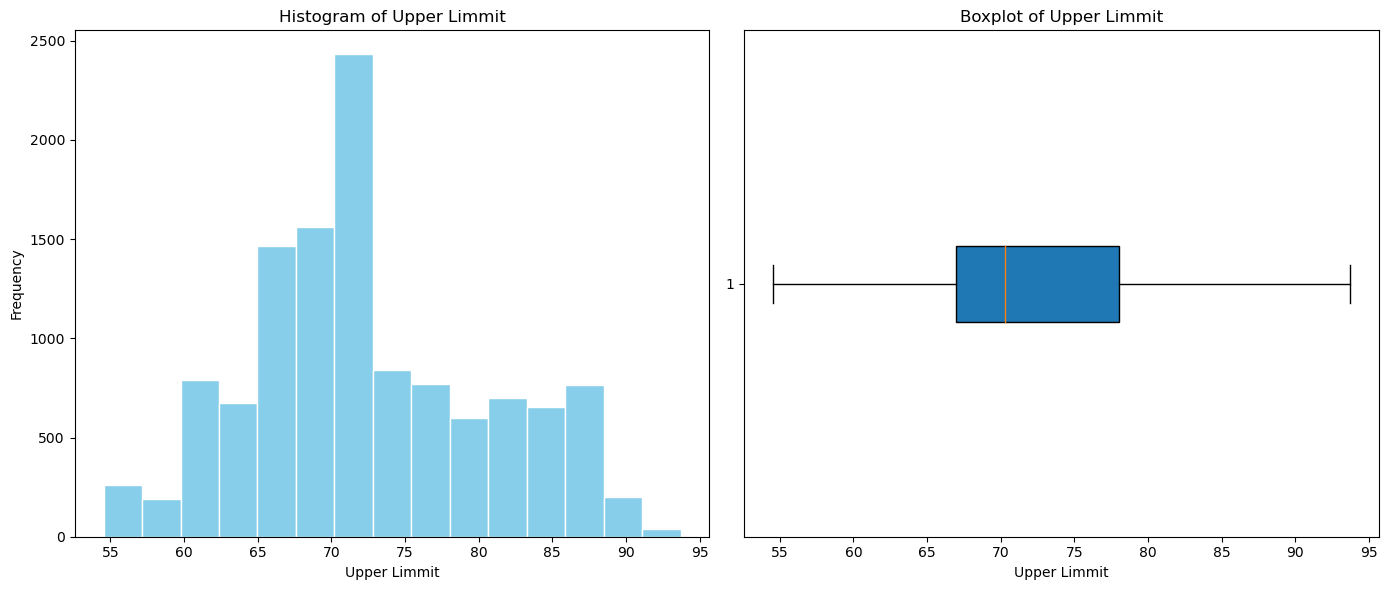

In [23]:
# Plotting histogram and boxplot for 'Uppper Limmit' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Upper Limmit'], bins=15, color='skyblue', edgecolor='white')
plt.title('Histogram of Upper Limmit')
plt.xlabel('Upper Limmit')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Upper Limmit'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Upper Limmit')
plt.xlabel('Upper Limmit')

plt.tight_layout()
plt.savefig('visualizations/upper.png')
plt.show()

### Upper Limit Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the upper limit distribution of a dataset.

- **Histogram**: 
  - Most common upper limit range: around 70.
  - Less frequent upper limit values: below 60 and above 85.
- **Boxplot**: 
  - Median upper limit around 70.
  - Upper limit range: 55 to 95.
- **Summary**: 
  - Upper limit values are most commonly around 70.
  - No significant outliers.


-------------------------------

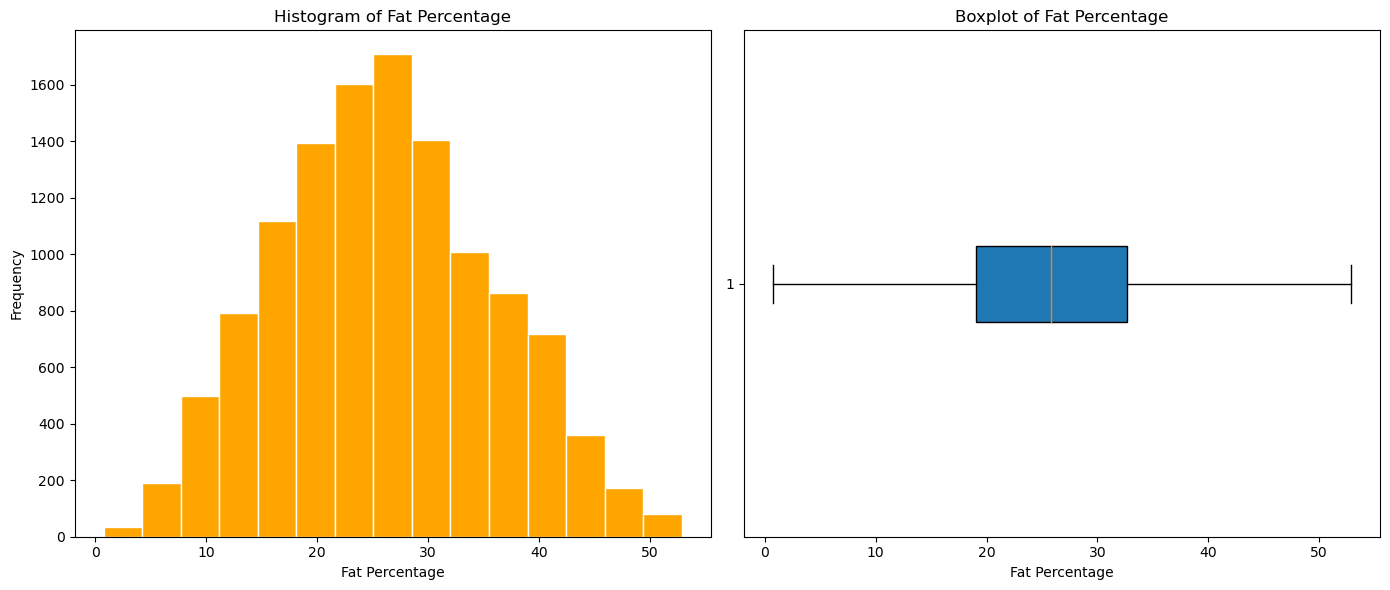

In [24]:
# Plotting histogram and boxplot for 'fat Percentage' column
plt.figure(figsize=(14, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['Fat Percentage'], bins=15, color='orange', edgecolor='white')
plt.title('Histogram of Fat Percentage')
plt.xlabel('Fat Percentage')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['Fat Percentage'], vert=False, patch_artist=True, boxprops=dict())
plt.title('Boxplot of Fat Percentage')
plt.xlabel('Fat Percentage')

plt.tight_layout()
plt.savefig('visualizations/bodyFat.png')
plt.show()

### Fat Percentage Distribution Analysis

The image consists of two charts: a histogram and a boxplot, both representing the fat percentage distribution of a dataset.

- **Histogram**: 
  - Most common fat percentage range: 25-30%.
  - Less frequent fat percentages: below 10% and above 40%.
- **Boxplot**: 
  - Median fat percentage around 25%.
  - Fat percentage range: 5% to 50%.
- **Summary**: 
  - Fat percentages are most commonly around 25-30%.
  - No significant outliers.


---------------------

### 2. Visualizing Sex distributions & Health conditions by using piechart with Matplotlib

========================================================================================

#### Visualize Sex distributions

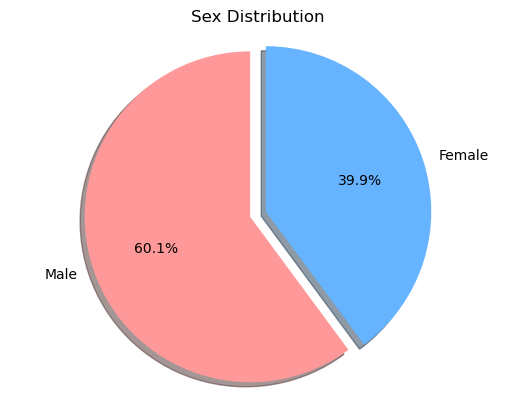

In [25]:
# Count the occurrences of each category in the 'Sex' column
sex_counts = df['Sex'].value_counts()

# Data for the pie chart
labels = sex_counts.index
sizes = sex_counts.values
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode 1st slice

# Create the pie chart
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Title
plt.title('Sex Distribution')
plt.savefig('visualizations/sex.png')

# Display the chart
plt.show()

### Sex Distribution

The pie chart shows the distribution of males and females in the dataset.

- **Males**: Represented by the pink section, making up 60.1% of the total.
- **Females**: Represented by the blue section, making up 39.9% of the total.

#### Summary
There are more males (60.1%) than females (39.9%) in this dataset.


------------------------

#### Visualize Health Conditions

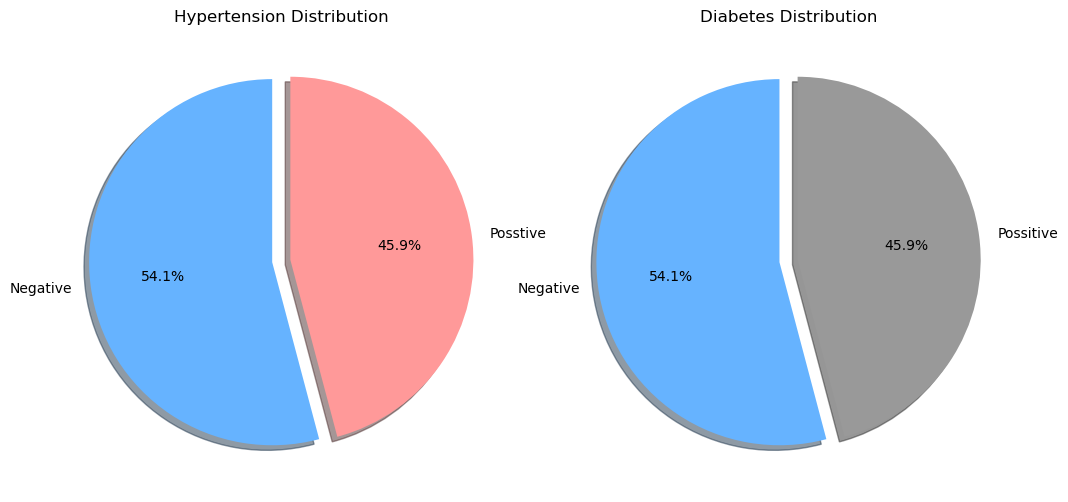

In [26]:
# Hypertension Distribution
hypertension_counts = df['Hypertension'].value_counts()
labels_hypertension = ['Negative', 'Posstive']
sizes_hypertension = hypertension_counts.values
colors_hypertension = ['#66b3ff', '#ff9999']
explode_hypertension = (0, 0.1)  # explode 2nd slice

# Diabetes Distribution
diabetes_counts = df['Diabetes'].value_counts()
labels_diabetes = ['Negative', 'Possitive']
sizes_diabetes = diabetes_counts.values
colors_diabetes = ['#66b3ff', '#999']
explode_diabetes = (0, 0.1)  # explode 2nd slice

# Create the pie charts in one row
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Hypertension Pie Chart
ax1.pie(sizes_hypertension, explode=explode_hypertension, labels=labels_hypertension, colors=colors_hypertension, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Hypertension Distribution')

# Diabetes Pie Chart
ax2.pie(sizes_diabetes, explode=explode_diabetes, labels=labels_diabetes, colors=colors_diabetes, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax2.set_title('Diabetes Distribution')

# Display the charts & save
plt.savefig('visualizations/health_conditions.png')
plt.show()

### Health Conditions Distribution

The image contains two pie charts showing the distribution of health conditions (Hypertension and Diabetes) among individuals.

#### Hypertension Distribution
- **Negative**: Represented by the blue section, making up 54.1% of the total.
- **Positive**: Represented by the pink section, making up 45.9% of the total.

#### Diabetes Distribution
- **Negative**: Represented by the blue section, making up 54.1% of the total.
- **Positive**: Represented by the gray section, making up 45.9% of the total.

#### Summary
- For both health conditions, a slightly higher percentage of individuals are negative (54.1%) compared to positive (45.9%).


---------------------------

#### Visualize Health Gender of Hypertension Distribution 

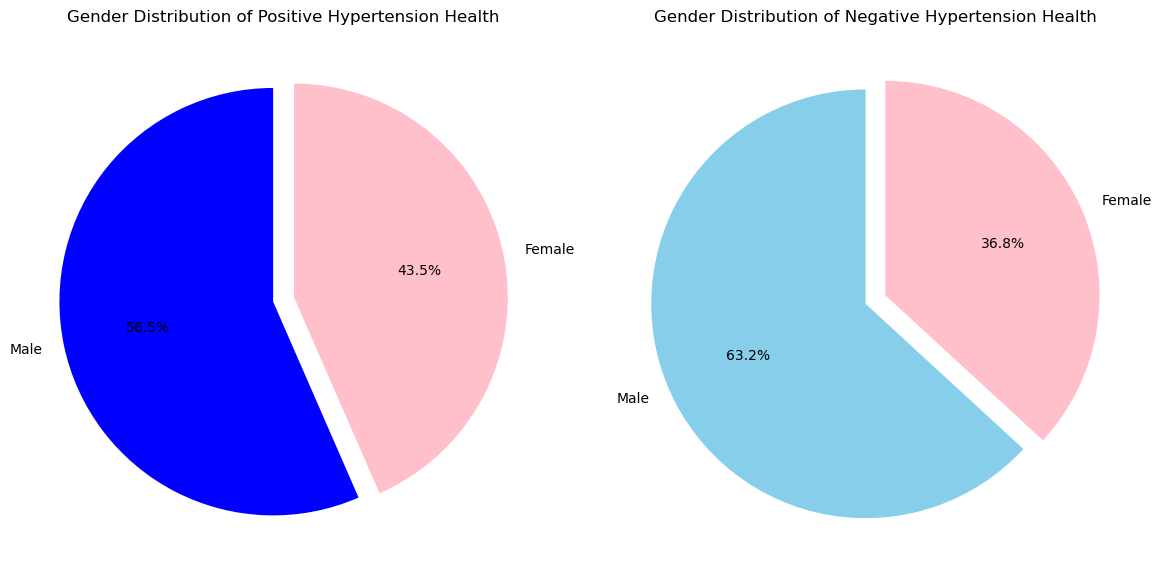

In [27]:
# Filter the dataframe for 'Yes' and 'No' decisions in Hypertension
positive_hypertension = df[df['Hypertension'] == 'Yes']
negative_hypertension = df[df['Hypertension'] == 'No']

# Count the number of male and female individuals with 'Yes' and 'No' decisions in Hypertension
gender_positive_counts = positive_hypertension['Sex'].value_counts()
gender_negative_counts = negative_hypertension['Sex'].value_counts()

# Creating the pie charts in one row
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Positive Hypertension Pie Chart
ax1.pie(gender_positive_counts, labels=gender_positive_counts.index, autopct='%1.1f%%', startangle=90, colors=['blue', 'pink'], explode=(0, 0.1))
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Gender Distribution of Positive Hypertension Health')

# Negative Hypertension Pie Chart
ax2.pie(gender_negative_counts, labels=gender_negative_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'pink'], explode=(0, 0.1))
ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax2.set_title('Gender Distribution of Negative Hypertension Health')

# Save the figure
plt.savefig('visualizations/gender_hypertension_distribution.png')

# Display the charts
plt.show()

### Gender Distribution of Hypertension Health

The image contains two pie charts showing the gender distribution of individuals with positive and negative hypertension health.

#### Gender Distribution of Positive Hypertension Health
- **Male**: Represented by the blue section, making up 56.5% of the total.
- **Female**: Represented by the pink section, making up 43.5% of the total.

#### Gender Distribution of Negative Hypertension Health
- **Male**: Represented by the light blue section, making up 63.2% of the total.
- **Female**: Represented by the pink section, making up 36.8% of the total.

#### Summary
- A higher percentage of males have both positive (56.5%) and negative (63.2%) hypertension health compared to females.
- Females account for 43.5% of positive and 36.8% of negative hypertension health cases.


________________________

#### Visualize Health Gender of Diabates Distribution 

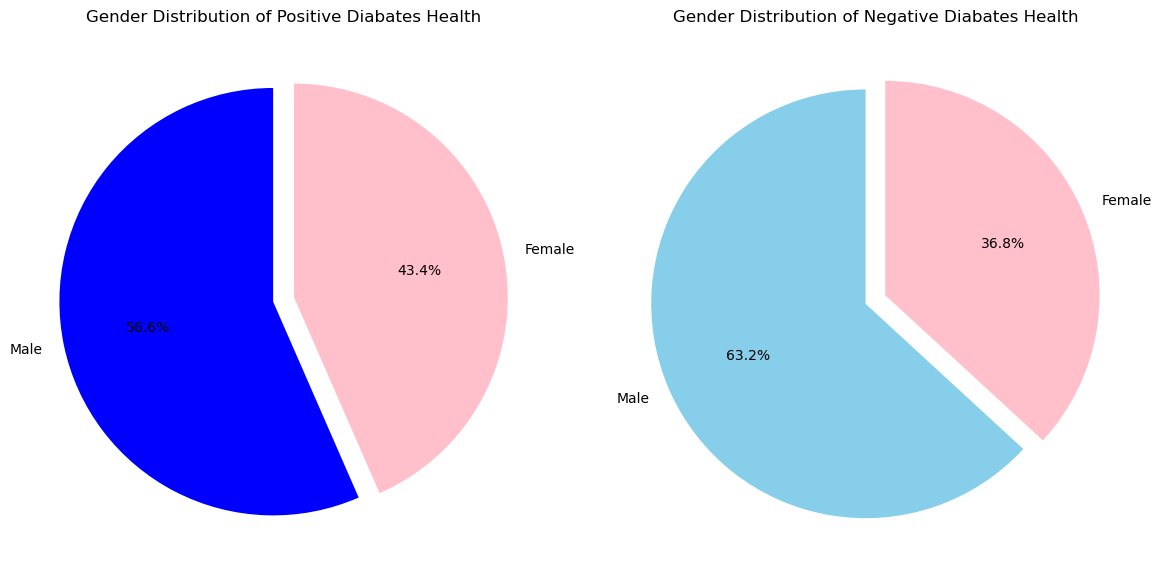

In [28]:
# Filter the dataframe for 'Yes' and 'No' decisions in Diabates
positive_hypertension = df[df['Diabetes'] == 'Yes']
negative_hypertension = df[df['Diabetes'] == 'No']

# Count the number of male and female individuals with 'Yes' and 'No' decisions in Hypertension
gender_positive_counts = positive_hypertension['Sex'].value_counts()
gender_negative_counts = negative_hypertension['Sex'].value_counts()

# Creating the pie charts in one row
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Positive Hypertension Pie Chart
ax1.pie(gender_positive_counts, labels=gender_positive_counts.index, autopct='%1.1f%%', startangle=90, colors=['blue', 'pink'], explode=(0, 0.1))
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title('Gender Distribution of Positive Diabates Health')

# Negative Hypertension Pie Chart
ax2.pie(gender_negative_counts, labels=gender_negative_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'pink'], explode=(0, 0.1))
ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax2.set_title('Gender Distribution of Negative Diabates Health')

# Save the figure
plt.savefig('visualizations/gender_diabates_distribution.png')

# Display the charts
plt.show()

### Gender Distribution of Diabetes Health

The image contains two pie charts showing the gender distribution of individuals with positive and negative diabetes health.

#### Gender Distribution of Positive Diabetes Health
- **Male**: Represented by the blue section, making up 56.6% of the total.
- **Female**: Represented by the pink section, making up 43.4% of the total.

#### Gender Distribution of Negative Diabetes Health
- **Male**: Represented by the light blue section, making up 63.2% of the total.
- **Female**: Represented by the pink section, making up 36.8% of the total.

#### Summary
- A higher percentage of males have both positive (56.6%) and negative (63.2%) diabetes health compared to females.
- Females account for 43.4% of positive and 36.8% of negative diabetes health cases.


-----------------------------

### 3. Visualization Categorical variables using Bar chart with Searbon

=======================================================================

#### Visualize Fitness Level

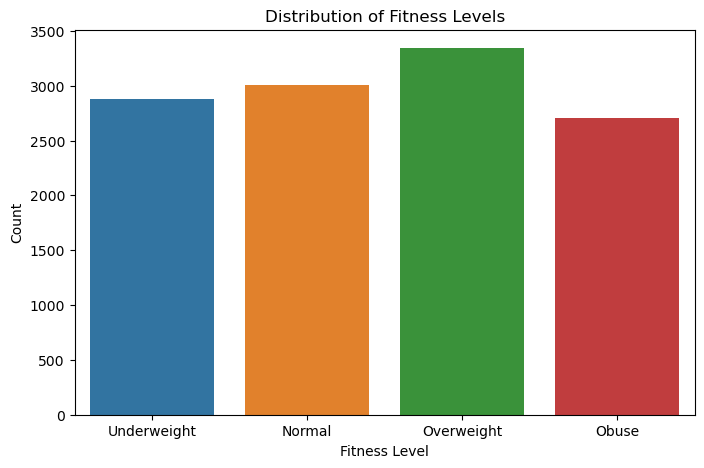

In [29]:
# Display Fitness Level
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Level')
plt.title('Distribution of Fitness Levels')
plt.xlabel('Fitness Level')
plt.ylabel('Count')
plt.savefig('visualizations/fitness_levels.png')
plt.show()

### Distribution of Fitness Levels

The bar chart shows the distribution of different fitness levels among individuals.

#### Fitness Levels
- **Underweight**: Represents the count of individuals who are classified as underweight.
- **Normal**: Represents the count of individuals who are classified as having a normal weight.
- **Overweight**: Represents the count of individuals who are classified as overweight.
- **Obese**: Represents the count of individuals who are classified as obese.

#### Summary
- **Underweight**: There are fewer individuals classified as underweight compared to other fitness levels.
- **Normal**: A significant number of individuals fall into the normal weight category.
- **Overweight**: The highest number of individuals are classified as overweight.
- **Obese**: A substantial number of individuals are classified as obese, but fewer than those classified as overweight.


----------------------------------

#### Visualize Fitness Goal

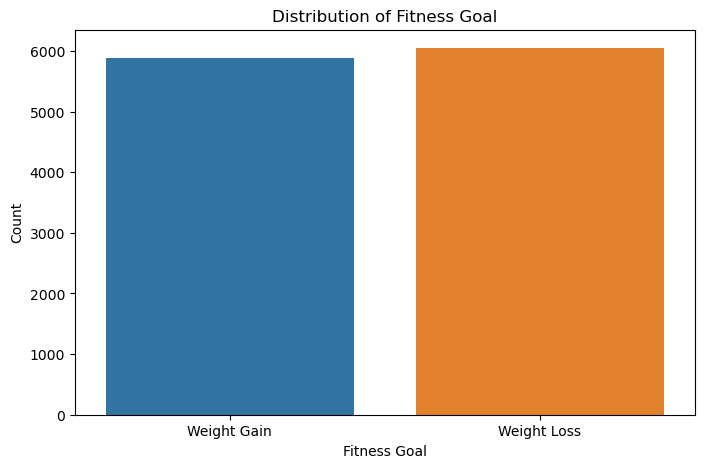

In [30]:
# Display Fintess Goal
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Fitness Goal')
plt.title('Distribution of Fitness Goal')
plt.xlabel('Fitness Goal')
plt.ylabel('Count')
plt.savefig('visualizations/fitness_goal.png')
plt.show()

### Distribution of Fitness Goals

The bar chart shows the distribution of different fitness goals among individuals.

#### Fitness Goals
- **Weight Gain**: Represents the count of individuals whose fitness goal is to gain weight.
- **Weight Loss**: Represents the count of individuals whose fitness goal is to lose weight.

#### Summary
- **Weight Gain**: A significant number of individuals have a goal to gain weight, making up a large portion of the dataset.
- **Weight Loss**: An equally significant number of individuals have a goal to lose weight, slightly higher than those aiming for weight gain.


------------------

#### Visualize Fitness Type

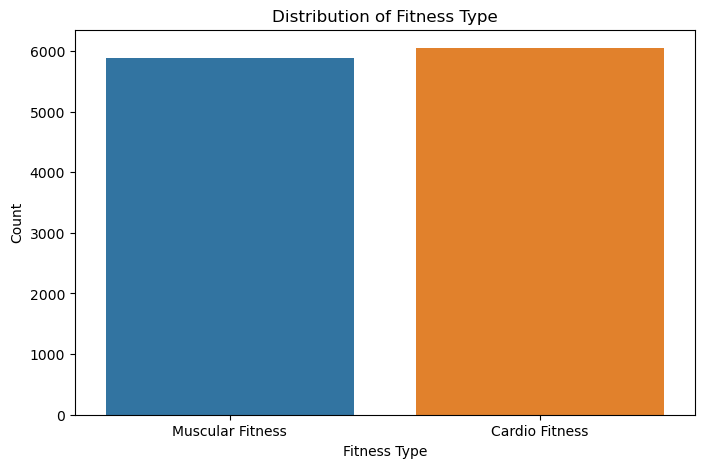

In [31]:
# Display Fitness Type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Fitness Type')
plt.title('Distribution of Fitness Type')
plt.xlabel('Fitness Type')
plt.ylabel('Count')
plt.savefig('visualizations/fitness_type.png')
plt.show()

### Distribution of Fitness Types

The bar chart shows the distribution of different fitness types among individuals.

#### Fitness Types
- **Muscular Fitness**: Represents the count of individuals focused on muscular fitness.
- **Cardio Fitness**: Represents the count of individuals focused on cardio fitness.

#### Summary
- **Muscular Fitness**: A significant number of individuals are focused on improving their muscular fitness.
- **Cardio Fitness**: An equally significant number of individuals are focused on improving their cardio fitness, slightly higher than those focusing on muscular fitness.




-------------------

=================================  END DATA VISUALIZATION ======================================

----------------------------

## Encoding categorical variables using LabelEncoder()

In [32]:
# initialize lbl
lbl=LabelEncoder()

df['Sex'] = lbl.fit_transform(df['Sex'])
df['Hypertension'] = lbl.fit_transform(df['Hypertension'])
df['Diabetes'] = lbl.fit_transform(df['Diabetes'])

#### Check if encoded

In [33]:
df.head(2)

,Sex,Age,Height,Weight,Hypertension,Diabetes,BMI,Level,Lower Limmit,Upper Limmit,Standard Weight,Fat Percentage,Fitness Goal,Fitness Type,Exercises,Equipment Required,Diet,Conclusion Recommendation
0,1,18,1.68,47.5,0,0,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...",Dumbbells and barbells,"Vegetables: (Carrots, Sweet Potato, and Lettuc...",Follow a regular exercise schedule. Adhere to ...
1,1,18,1.68,47.5,1,0,16.83,Underweight,52.21,70.28,52.21 (kg) - 70.28(kg),8.14,Weight Gain,Muscular Fitness,"Squats, deadlifts, bench presses, and overhead...","Light athletic shoes, resistance bands, and li...","Vegetables: (Tomatoes, Garlic, leafy greens, b...",Follow a regular exercise schedule. Adhere to ...


--------------------------------------------------------

### Removing Unwanted Features

In [34]:
df.drop(columns=['Standard Weight'], inplace=True)

#### Check if dropped

In [35]:
df.columns

Index(['Sex', 'Age', 'Height', 'Weight', 'Hypertension', 'Diabetes', 'BMI',
       'Level', 'Lower Limmit', 'Upper Limmit', 'Fat Percentage',
       'Fitness Goal', 'Fitness Type', 'Exercises', 'Equipment Required',
       'Diet', 'Conclusion Recommendation'],
      dtype='object')

-------------------------------------------------------------------

## Building Machine Learning Algorithms

### Separate features (X) and target variable (y) into Two Classes

==============================================================

### Regression Classes 
This classes we will use to predict numeric values eg:- (BMI, Lower Limmit, Upper, Limmit, and body fat percentage).

In [36]:
X = df[['Sex','Age','Height', 'Weight','Hypertension','Diabetes']]
yr = df[['BMI','Lower Limmit','Upper Limmit', 'Fat Percentage']] # yr-> y-Regression; our target varaibles according numerics

------------------------

### Classification Classes 
This classes we will use to predict text, classifcation values eg:- (Fitness Level, Fitness Gaol, Fitness Type, Excercies, Equipments, and Conclussion Recommendation).

In [37]:
X = df[['Sex','Age','Height', 'Weight','Hypertension','Diabetes']]
yc = df[['Level','Fitness Goal', 'Fitness Type', 'Exercises', 'Equipment Required', 'Diet','Conclusion Recommendation']]

---------

## Train Test Split
In this section also we split our dataset into two classes

In [38]:
# Split the data into training and testing sets correctly
X_train, X_test, yr_train, yr_test = train_test_split(X, yr, test_size=0.20, random_state=42) # Regression Classes

In [39]:
# Split the data into training and testing sets correctly
X_train, X_test, yc_train, yc_test = train_test_split(X, yc, test_size=0.20, random_state=42) # Classification Classes

-------------------------------------------------------

## Building Regression Models

====================================

## 1. Building decision tree regression model

In [45]:
# Initialize the decisontree model
dec_reg = DecisionTreeRegressor()

In [46]:
# Train the model on the training set
dec_reg.fit(X_train, yr_train)

DecisionTreeRegressor()

In [47]:
print("Score of training Decision Tree Regression Model: ", dec_reg.score(X_train, yr_train)* 100 )

Score of training Decision Tree Regression Model:  100.0


In [48]:
print("Score of testing Decision Tree Regression Model: ", dec_reg.score(X_test, yr_test)* 100 )

Score of testing Decision Tree Regression Model:  99.94629940610814


In [49]:
# Predict on the test set
yr_pred = dec_reg.predict(X_test)

In [50]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [51]:
# Create a DataFrame to display the metrics
metrics_df = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'R-squared (R²)'],
    'Value': [mae, mse, r2]
})

In [52]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


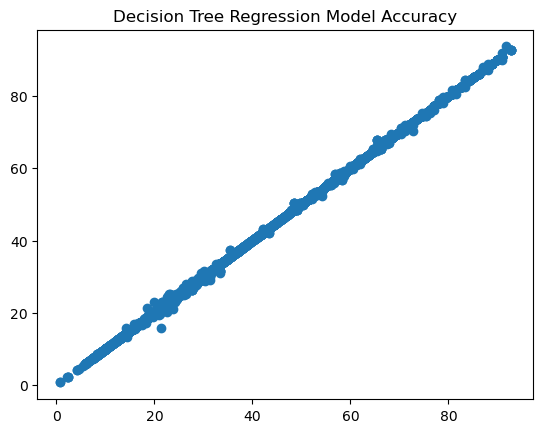

In [53]:
plt.title('Decision Tree Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/dec_reg.png')

------------------------------------------------------------

## 2. Building random forest regression model

In [54]:
ran_reg = RandomForestRegressor()
# Train the model
ran_reg.fit(X_train, yr_train)

RandomForestRegressor()

In [55]:
print("Score of training Random Forest Regression Model: ", ran_reg.score(X_train, yr_train)* 100 )

Score of training Random Forest Regression Model:  99.99387559502533


In [56]:
print("Score of testing Random foret Regression Model: ", ran_reg.score(X_test, yr_test)* 100 )

Score of testing Random foret Regression Model:  99.96841956005505


In [57]:
# Predict on the test set
yr_pred = ran_reg.predict(X_test)

In [58]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [59]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


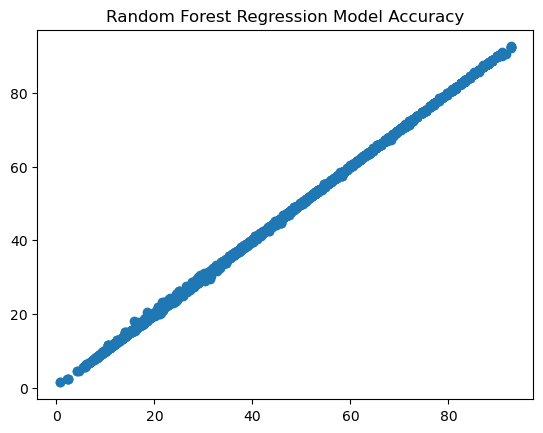

In [60]:
plt.title('Random Forest Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/ran_reg.png')

-------------------------------

## 3. Building KNN  regression model

In [61]:
knn_reg = KNeighborsRegressor()

knn_reg.fit(X_train, yr_train)

KNeighborsRegressor()

In [62]:
print("Score of training KNN Regression Model: ", knn_reg.score(X_train, yr_train)* 100 )

Score of training KNN Regression Model:  91.99448066694151


In [63]:
print("Score of testing KNN Regression Model: ", knn_reg.score(X_test, yr_test)* 100 )

Score of testing KNN Regression Model:  86.71315399517704


In [64]:
# Predict on the test set
yr_pred = knn_reg.predict(X_test)

In [65]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [66]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


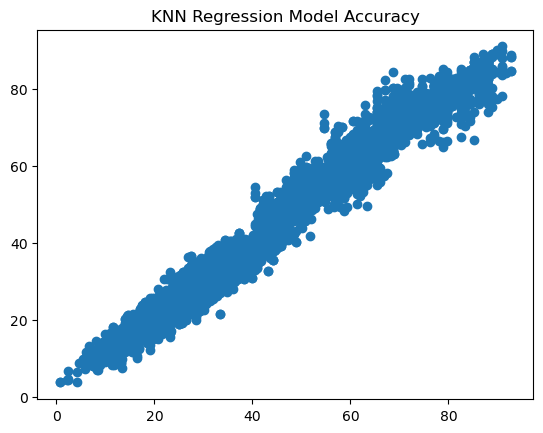

In [67]:
plt.title('KNN Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/ran_reg.png')

----------------------------------

## 4. Building Gradient Boosting regression model

In [68]:
gb_reg = MultiOutputRegressor(GradientBoostingRegressor())

gb_reg.fit(X_train, yr_train)

MultiOutputRegressor(estimator=GradientBoostingRegressor())

In [69]:
print("Score of training GradientBosting regression model: ", gb_reg.score(X_train, yr_train) * 100)

Score of training GradientBosting regression model:  99.85877806694984


In [70]:
print("Score of testing GradientBosting regression model: ", gb_reg.score(X_test, yr_test) * 100)

Score of testing GradientBosting regression model:  99.85361223279172


In [71]:
# Predict on the test set
yr_pred = gb_reg.predict(X_test)

In [72]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [73]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


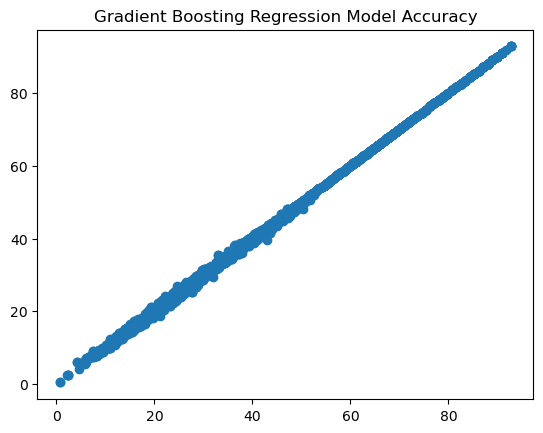

In [74]:
plt.title('Gradient Boosting Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/gb_reg.png')

---------------------------------

## 5. Building Ada Boost regression model

In [75]:
adb_reg = MultiOutputRegressor(AdaBoostRegressor())

adb_reg.fit(X_train, yr_train)

MultiOutputRegressor(estimator=AdaBoostRegressor())

In [76]:
print("Score of training AdaBoost Regression Model: ", adb_reg.score(X_train, yr_train))

Score of training AdaBoost Regression Model:  0.966266360119512


In [77]:
print("Score of testing AdaBoost Regression Model: ", adb_reg.score(X_test, yr_test))

Score of testing AdaBoost Regression Model:  0.9666531130609975


In [78]:
# Predict on the test set
yr_pred = adb_reg.predict(X_test)

In [79]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [80]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


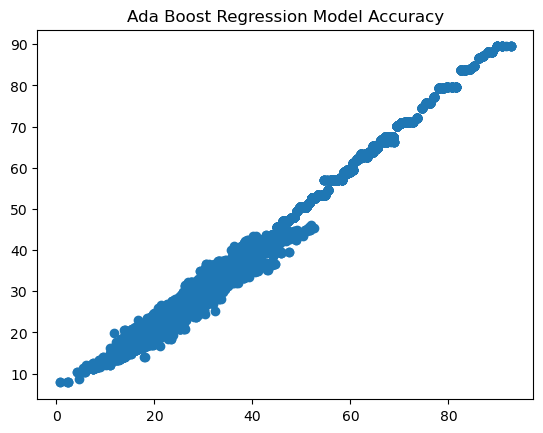

In [81]:
plt.title('Ada Boost Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/adb_reg.png')

-----------------------

## 6. Building Linear  regression model

In [82]:
lin_reg = LinearRegression()

lin_reg.fit(X_train, yr_train)

LinearRegression()

In [83]:
print("Score of training Linear Regression Model: ", lin_reg.score(X_train, yr_train) * 100)

Score of training Linear Regression Model:  99.37266973482919


In [84]:
print("Score of testing Linear Regression Model: ", lin_reg.score(X_test, yr_test) * 100)

Score of testing Linear Regression Model:  99.38108082647574


In [85]:
# Predict on the test set
yr_pred = lin_reg.predict(X_test)

In [86]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [87]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


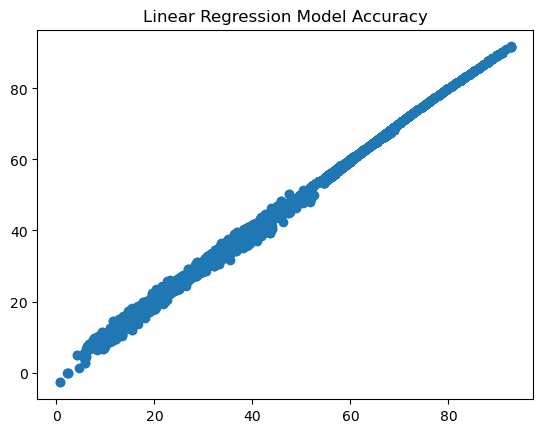

In [88]:
plt.title('Linear Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/lin_reg.png')

-----------------

## 7. Building SVM  regression model

In [89]:
svm_reg = MultiOutputRegressor(SVR())

svm_reg.fit(X_train, yr_train)

MultiOutputRegressor(estimator=SVR())

In [90]:
print("Score of training SVM Regression Model: ", svm_reg.score(X_train, yr_train) * 100)

Score of training SVM Regression Model:  48.17891401708847


In [91]:
print("Score of testing SVM Regression Model: ", svm_reg.score(X_test, yr_test) * 100)

Score of testing SVM Regression Model:  48.46755038231315


In [92]:
# Predict on the test set
yr_pred = svm_reg.predict(X_test)

In [93]:
# Evaluate the model
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

In [94]:
# Display as table
print(metrics_df)

                      Metric     Value
0  Mean Absolute Error (MAE)  0.029946
1   Mean Squared Error (MSE)  0.034816
2             R-squared (R²)  0.999463


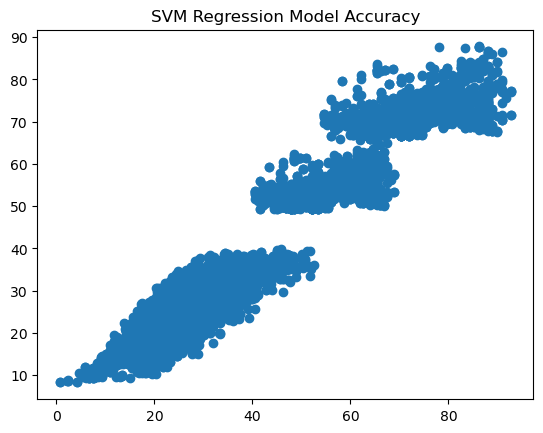

In [95]:
plt.title('SVM Regression Model Accuracy')
plt.scatter(yr_test,yr_pred)
plt.savefig('visualizations/svm_reg.png')

-----------------------------------------------------

================================= END BULIDING REGRESSION MODELS ====================================

---------------------------------------------

## Building Classification Models

=======================================

## 1. Building decision tree classfication model

In [135]:
dec_clf = MultiOutputClassifier(DecisionTreeClassifier())

dec_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=DecisionTreeClassifier())

In [136]:
print("Score of traing Decision Tree Classification Model: ", dec_clf.score(X_train, yc_train) * 100)

Score of traing Decision Tree Classification Model:  99.19354838709677


In [137]:
print("Score of testing Decision Tree Classification Model: ", dec_clf.score(X_test, yc_test) * 100)

Score of testing Decision Tree Classification Model:  90.03350083752095


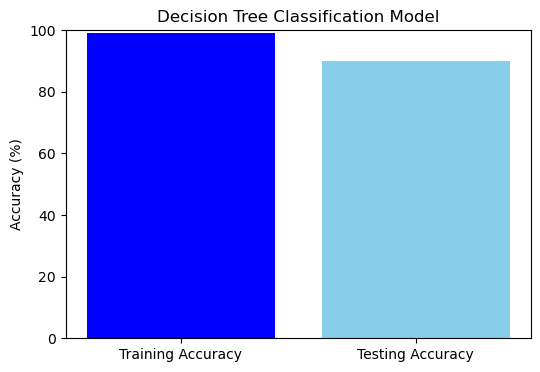

In [99]:
training_accuracy = round(dec_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(dec_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('Decision Tree Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/dec_clf.png')
plt.show()


-----------------------------------------

## 2. Building random forest classfication model

In [100]:
ran_clf = MultiOutputClassifier(RandomForestClassifier())

ran_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=RandomForestClassifier())

In [101]:
print("Score of traing Random Forest Classification Model: ", ran_clf.score(X_train, yc_train) * 100)

Score of traing Random Forest Classification Model:  99.21449518223712


In [102]:
print("Score of testing Random Forest Classification Model: ", ran_clf.score(X_test, yc_test) * 100)

Score of testing Random Forest Classification Model:  89.86599664991624


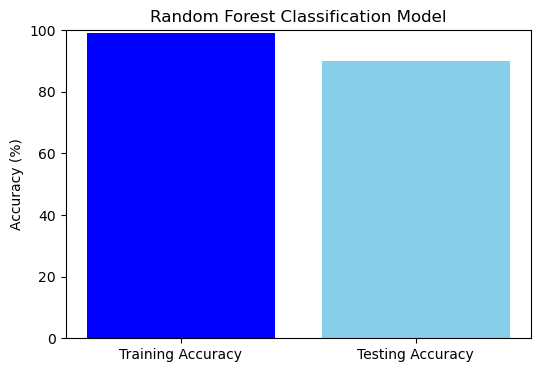

In [103]:
training_accuracy = round(ran_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(ran_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('Random Forest Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/ran_clf.png')
plt.show()


-------------------------------

## 3. Building KNN  classfication model

In [104]:
# Convert categorical features to numerical using one-hot encoding
X_encoded = pd.get_dummies(X, columns=['Sex', 'Hypertension', 'Diabetes'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, yc_train, yc_test = train_test_split(X_encoded, yc, test_size=0.2, random_state=42)

# Initialize the multi-output classifier with KNeighborsClassifier
knn_clf = MultiOutputClassifier(KNeighborsClassifier(n_neighbors=100))

# Fit the model on the training set
knn_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=KNeighborsClassifier(n_neighbors=100))

In [105]:
print("Score of traing KNN Classification Model: ", knn_clf.score(X_train, yc_train) * 100)

Score of traing KNN Classification Model:  16.097612065354


In [106]:
print("Score of testing KNN Classification Model: ", knn_clf.score(X_test, yc_test) * 100)

Score of testing KNN Classification Model:  12.814070351758794


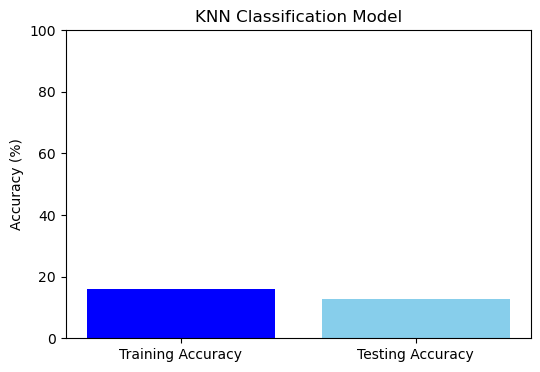

In [107]:
training_accuracy = round(knn_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(knn_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('KNN Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/knn_clf.png')
plt.show()


-----------------------------------

## 4. Building Gradient Boosting classification model

In [108]:
gb_clf = MultiOutputClassifier(GradientBoostingClassifier())

gb_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=GradientBoostingClassifier())

In [109]:
print("Score of traing Gradient Boosting Classification Model: ", gb_clf.score(X_train, yc_train) * 100)

Score of traing Gradient Boosting Classification Model:  89.93506493506493


In [110]:
print("Score of testing Gradient Boosting Classification Model: ", gb_clf.score(X_test, yc_test) * 100)

Score of testing Gradient Boosting Classification Model:  89.40536013400336


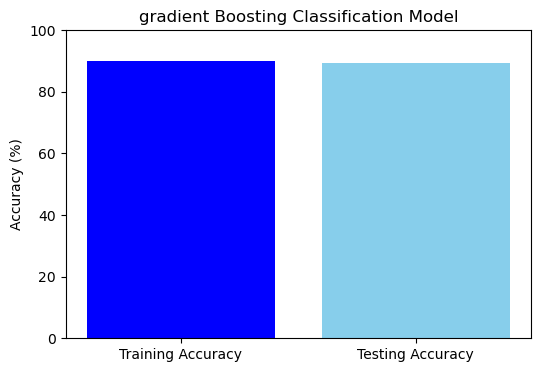

In [111]:
training_accuracy = round(gb_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(gb_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('gradient Boosting Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/gb_clf.png')
plt.show()


------------------------------------

## 5. Building Ada Boost classification model

In [112]:
adb_clf = MultiOutputClassifier(AdaBoostClassifier())

adb_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=AdaBoostClassifier())

In [113]:
print("Score of traing Ada Boost Classification Model: ", adb_clf.score(X_train, yc_train) * 100)

Score of traing Ada Boost Classification Model:  5.090071219103478


In [114]:
print("Score of testing Ada Boost Classification Model: ", adb_clf.score(X_test, yc_test) * 100)

Score of testing Ada Boost Classification Model:  4.731993299832496


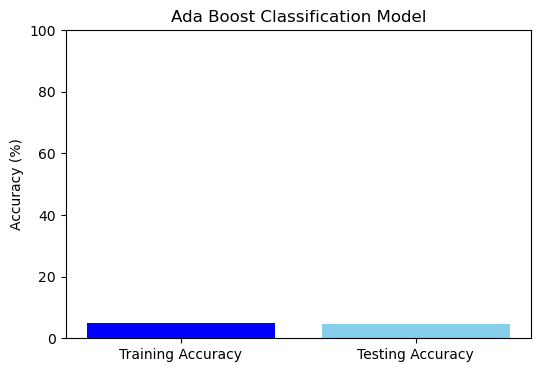

In [115]:
training_accuracy = round(adb_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(adb_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('Ada Boost Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/adb_clf.png')
plt.show()


-----------------------------

## 6. Building  Logistic  Regession model

In [116]:
# Create a pipeline that first scales the data then applies logistic regression
log_clf = MultiOutputClassifier(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)))
log_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=Pipeline(steps=[('standardscaler',
                                                 StandardScaler()),
                                                ('logisticregression',
                                                 LogisticRegression(max_iter=1000))]))

In [117]:
print("Score of traing Logistic Regression Model: ", log_clf.score(X_train, yc_train) * 100)

Score of traing Logistic Regression Model:  85.59907834101382


In [118]:
print("Score of testing Logistic Regression Model: ", log_clf.score(X_test, yc_test) * 100)

Score of testing Logistic Regression Model:  86.51591289782245


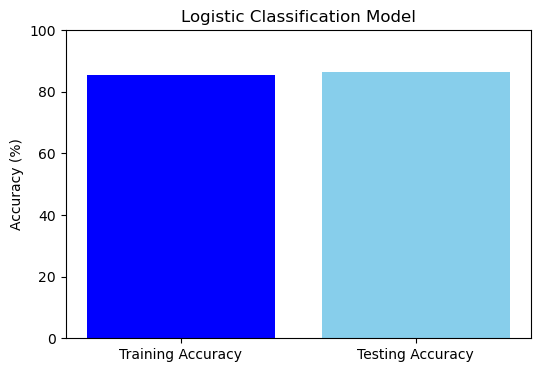

In [119]:
training_accuracy = round(log_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(log_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('Logistic Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/log_clf.png')
plt.show()


--------------------

## 7. Building SVM classification model

In [120]:
svm_clf = MultiOutputClassifier(SVC())

svm_clf.fit(X_train, yc_train)

MultiOutputClassifier(estimator=SVC())

In [121]:
print("Score of traing SVM Classification Model: ", svm_clf.score(X_train, yc_train) * 100)

Score of traing SVM Classification Model:  3.100125680770842


In [122]:
print("Score of testing SVM Classification Model: ", svm_clf.score(X_test, yc_test) * 100)

Score of testing SVM Classification Model:  3.1407035175879394


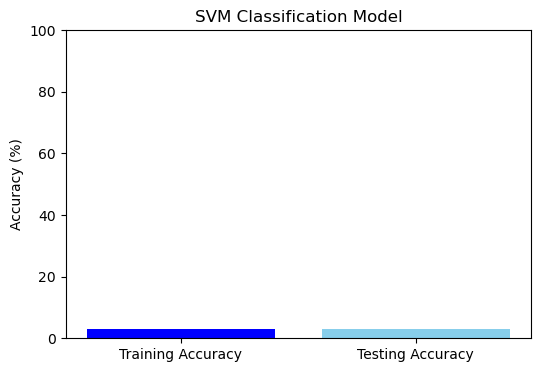

In [123]:
training_accuracy = round(svm_clf.score(X_train,yc_train)*100,2)
testing_accuracy = round(svm_clf.score(X_test,yc_test)*100,2)

# Plotting
plt.figure(figsize=(6, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('SVM Classification Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.savefig('visualizations/svm_clf.png')
plt.show()


-----------------------------------

======================================== END BUILDING CLASSFICATION MODEL ========================================

----------------------------------------------------

## Model Improvment by using SMOTEENN() and Hyper Parameter Tunning
In this section we will improve decision tree model that our selected model when comparing other models

In [124]:
sm = SMOTEENN()
# Setting up and training the MultiOutputClassifier with RandomForest
model_dt_smote = MultiOutputClassifier(DecisionTreeClassifier(random_state=42))
model_dt_smote.fit(X_train, yc_train)

# Prediction
ydt_predict = model_dt_smote.predict(X_test)

# Evaluation
model_score_training = model_dt_smote.score(X_train, yc_train)
model_score_testing = model_dt_smote.score(X_test, yc_test)
print("After Model Improved the train is: ", round(model_score_training *100,2))
print("After Model Improved the test is: ", round(model_score_testing *100, 2))

After Model Improved the train is:  99.19
After Model Improved the test is:  89.7


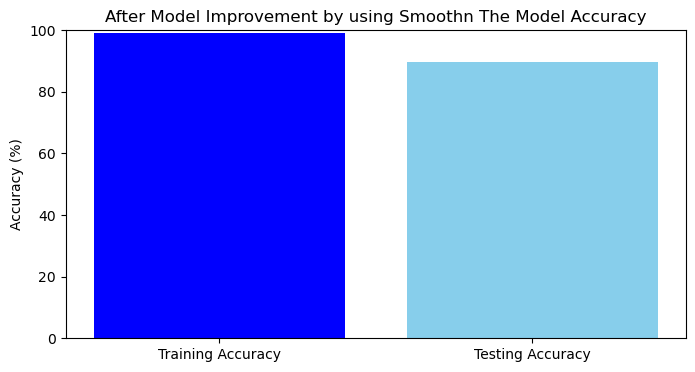

In [125]:
# Calculate accuracy for training and testing sets
training_accuracy = model_score_training * 100
testing_accuracy = model_score_testing * 100

# Plotting
plt.figure(figsize=(8, 4))
plt.bar(['Training Accuracy', 'Testing Accuracy'], [training_accuracy, testing_accuracy], color=['blue', 'skyblue'])
plt.title('After Model Improvement by using Smoothn The Model Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.show()

------------------------------------

### Hyper Parameter Tunning

In [126]:
# Define the parameter grid
param_grid = {
    'estimator__max_depth': [3, 5, 10, None],
    'estimator__min_samples_split': [2, 5, 10],
    'estimator__min_samples_leaf': [1, 2, 4],
    'estimator__max_features': [None, 'sqrt', 'log2']
}

In [127]:
# Create the MultiOutputClassifier with DecisionTreeClassifier and use GridSearchCV
grid_search = GridSearchCV(MultiOutputClassifier(DecisionTreeClassifier(random_state=42)),
                           param_grid, cv=5, verbose=1, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, yc_train)

# Print the best parameters found by the grid search
print("Best Parameters:", grid_search.best_params_)

# Get the best estimator from the grid search
best_dtree = grid_search.best_estimator_

# Evaluate the accuracy on the training and testing sets using the best estimator
print("The Decision Tree Model Accuracy For Training:", round(best_dtree.score(X_train, yc_train)*100,2))
print("The Decision Tree Model Accuracy For Testing:", round(best_dtree.score(X_test, yc_test)*100,2))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'estimator__max_depth': None, 'estimator__max_features': None, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}
The Decision Tree Model Accuracy For Training: 99.19
The Decision Tree Model Accuracy For Testing: 89.7


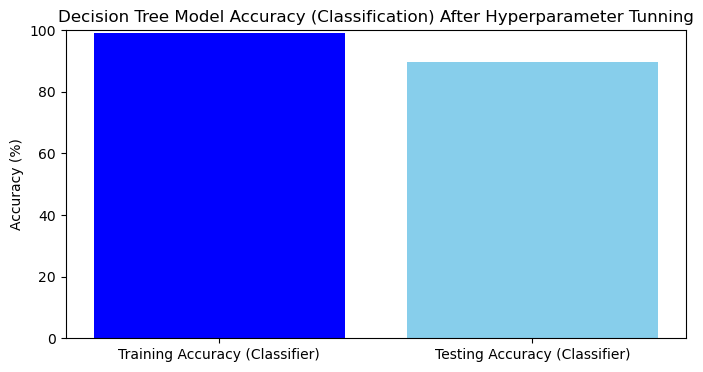

In [128]:
# Calculate accuracy for training and testing sets
training_accuracy_classifier = best_dtree.score(X_train, yc_train) * 100
testing_accuracy_classifier = best_dtree.score(X_test, yc_test) * 100

# Plotting
plt.figure(figsize=(8, 4))
plt.bar(['Training Accuracy (Classifier)', 'Testing Accuracy (Classifier)'], 
        [training_accuracy_classifier, testing_accuracy_classifier], 
        color=['blue', 'skyblue'])
plt.title('Decision Tree Model Accuracy (Classification) After Hyperparameter Tunning')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)  # Set y-axis limit from 0 to 100
plt.show()

---------------------------------

## Model Selection & Deployment
We selected decison tree model for both classification and regression model with heigh performace 

In [131]:
from joblib import dump

# Save Regression Models in regressions folder
dump(dec_reg, 'models/regressions/decission_tree_regressor.joblib') # we selected this model to predict our nemeric varaibles
dump(ran_reg, 'models/regressions/random_forest_regressor.joblib')
dump(knn_reg, 'models/regressions/knn_regressor.joblib')
dump(gb_reg, 'models/regressions/gradient_regressor.joblib')
dump(adb_reg, 'models/regressions/adaboost_regressor.joblib')
dump(lin_reg, 'models/regressions/lin_regressor.joblib')
dump(svm_reg, 'models/regressions/svm_regressor.joblib')

# Save Regression Models in regressions folder
dump(dec_clf, 'models/classifications/decission_tree_classifier.joblib') # we selected this model to predict our category 
dump(ran_clf, 'models/classifications/ran_classifier.joblib')
dump(knn_clf, 'models/classifications/knn_classifier.joblib')
dump(gb_clf, 'models/classifications/gradient_classifier.joblib')
dump(adb_clf, 'models/classifications/adaboost_classifier.joblib')
dump(log_clf, 'models/classifications/logistict_classifier.joblib')
dump(svm_clf, 'models/classifications/svm_classifier.joblib')

print("Successfully Deployed ✅")

Successfully Deployed ✅


## END PROJECT 😍